In [2]:
## Libraries

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from fredapi import Fred

import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# Data loading script

df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# Tell Pandas date is our index 
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,llp,unemployment,indpro,recession,term_spread,total_loans,llp_ratio,optimism_index
DATE,,,,,,,,
1986-01-01,4727.716,7.033333,55.355800,0.0,1.448000,1.436639e+06,0.003291,100.513167
1986-04-01,5545.933,7.166667,55.021467,0.0,1.277031,1.463927e+06,0.003788,101.420000
1986-07-01,5254.408,6.966667,55.237800,0.0,1.621406,1.493164e+06,0.003519,99.079233
1986-10-01,7171.896,6.833333,55.857800,0.0,1.761935,1.528918e+06,0.004691,98.987867
1987-01-01,5502.244,6.600000,56.608500,0.0,1.495738,1.577870e+06,0.003487,100.634667


In [4]:
# Regression Carryover

# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ================================
# 2. Load Data
# ================================
df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

df = df.sort_index()

# ================================
# 3. Construct First Differences
# ================================
df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dindpro"] = df["indpro"].diff()
df["dspread"] = df["term_spread"].diff()
df["doptimism"] = df["optimism_index"].diff()

# ================================
# 4. Create Lagged Variables (0–3)
# ================================
for k in range(0, 4):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)
    df[f"dindpro_lag{k}"] = df["dindpro"].shift(k)
    df[f"dspread_lag{k}"] = df["dspread"].shift(k)
    df[f"doptimism_lag{k}"] = df["doptimism"].shift(k)

# ================================
# 5. Build Regression Datasets
# ================================

# Unemployment-only
cols_unemp = ["dllp_ratio"] + [f"dunemp_lag{k}" for k in range(0,4)]
df_unemp = df[cols_unemp].dropna()

# Optimism-only
cols_opt = ["dllp_ratio"] + [f"doptimism_lag{k}" for k in range(0,4)]
df_opt = df[cols_opt].dropna()

# Multi-signal
cols_multi = ["dllp_ratio"] + \
             [f"dunemp_lag{k}" for k in range(0,4)] + \
             [f"dindpro_lag{k}" for k in range(0,4)] + \
             [f"dspread_lag{k}" for k in range(0,4)] + \
             [f"doptimism_lag{k}" for k in range(0,4)]

df_multi = df[cols_multi].dropna()

# ================================
# 6. Run Regressions
# ================================

# Unemployment model
X_unemp = sm.add_constant(df_unemp[[f"dunemp_lag{k}" for k in range(0,4)]])
y_unemp = df_unemp["dllp_ratio"]
model_unemp = sm.OLS(y_unemp, X_unemp).fit(cov_type="HC1")

# Optimism model
X_opt = sm.add_constant(df_opt[[f"doptimism_lag{k}" for k in range(0,4)]])
y_opt = df_opt["dllp_ratio"]
model_opt = sm.OLS(y_opt, X_opt).fit(cov_type="HC1")

# Multi-signal model
X_multi = sm.add_constant(df_multi.drop(columns=["dllp_ratio"]))
y_multi = df_multi["dllp_ratio"]
model_multi = sm.OLS(y_multi, X_multi).fit(cov_type="HC1")

# ================================
# 7. Print Summaries (optional)
# ================================
print(model_unemp.summary())
print(model_opt.summary())
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     5.723
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000257
Time:                        13:58:20   Log-Likelihood:                 782.88
No. Observations:                 156   AIC:                            -1556.
Df Residuals:                     151   BIC:                            -1541.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.747e-05      0.000     -0.214      

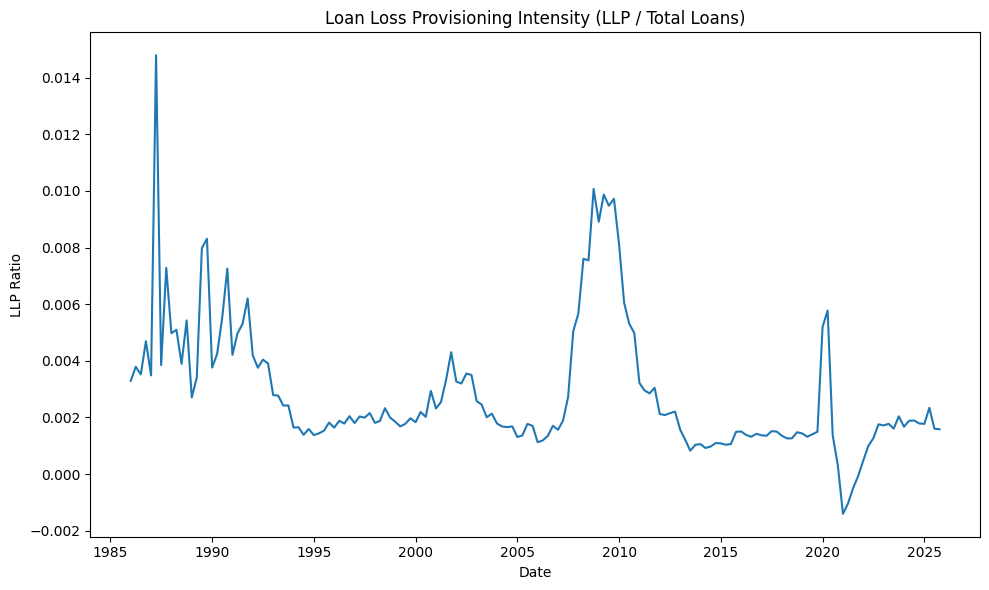

In [5]:
# Figure 1 - LLP ratio over time

plt.figure(figsize=(10,6))
plt.plot(df.index, df["llp_ratio"])
plt.title("Loan Loss Provisioning Intensity (LLP / Total Loans)")
plt.ylabel("LLP Ratio")
plt.xlabel("Date")
plt.tight_layout()
#plt.savefig("../figures/llp_ratio.png", dpi=300, bbox_inches='tight')
plt.show()

#plt.savefig("../figures/llp_ratio.png", dpi=300, bbox_inches='tight')

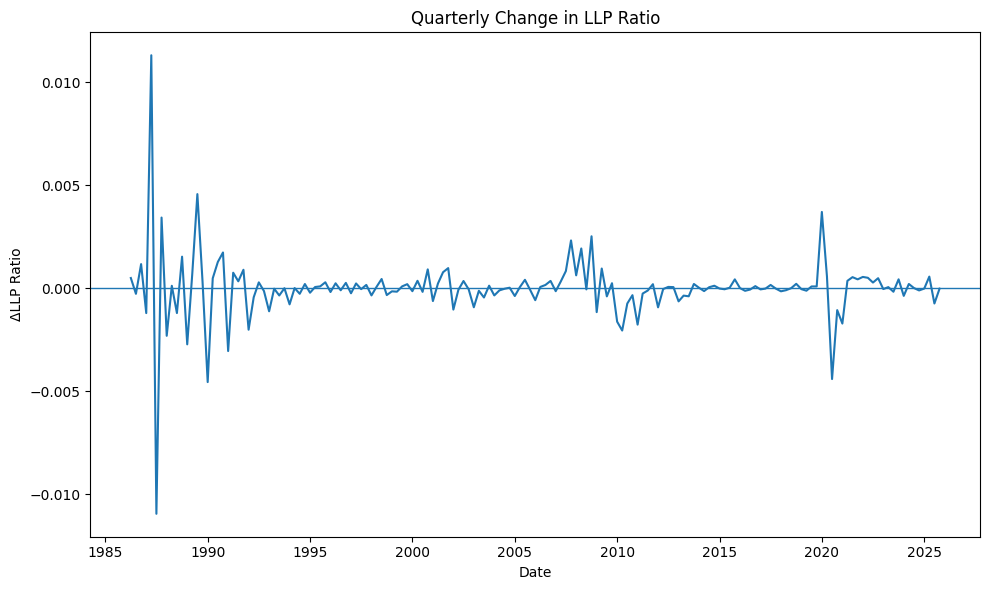

In [6]:
# Delta LLP
df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp_ratio"])
plt.axhline(0, linewidth=1)
plt.title("Quarterly Change in LLP Ratio")
plt.ylabel("ΔLLP Ratio")
plt.xlabel("Date")
plt.tight_layout()
#plt.savefig("../figures/dllp_ratio.png", dpi=300, bbox_inches='tight')
plt.show()

#plt.savefig("../figures/dllp_ratio.png", dpi=300, bbox_inches='tight')

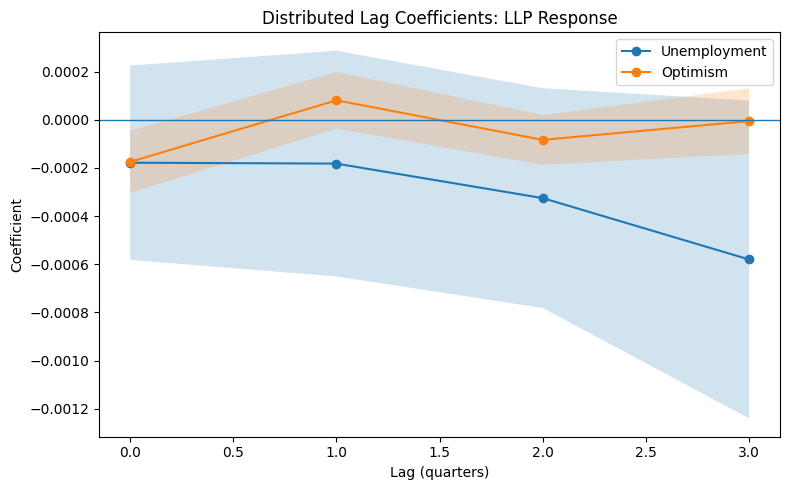

In [7]:
# Coefficient profile

import numpy as np
import matplotlib.pyplot as plt

lags = np.arange(0, 4)

# Coefficients
coef_unemp = np.array([model_multi.params[f"dunemp_lag{k}"] for k in lags])
coef_opt = np.array([model_multi.params[f"doptimism_lag{k}"] for k in lags])

# Standard errors
se_unemp = np.array([model_multi.bse[f"dunemp_lag{k}"] for k in lags])
se_opt = np.array([model_multi.bse[f"doptimism_lag{k}"] for k in lags])

plt.figure(figsize=(8,5))

# Plot lines
plt.plot(lags, coef_unemp, marker='o', label="Unemployment")
plt.plot(lags, coef_opt, marker='o', label="Optimism")

# Confidence intervals (±1.96*SE)
plt.fill_between(lags, coef_unemp - 1.96*se_unemp, coef_unemp + 1.96*se_unemp, alpha=0.2)
plt.fill_between(lags, coef_opt - 1.96*se_opt, coef_opt + 1.96*se_opt, alpha=0.2)

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Distributed Lag Coefficients: LLP Response")
plt.legend()

plt.tight_layout()
plt.show()

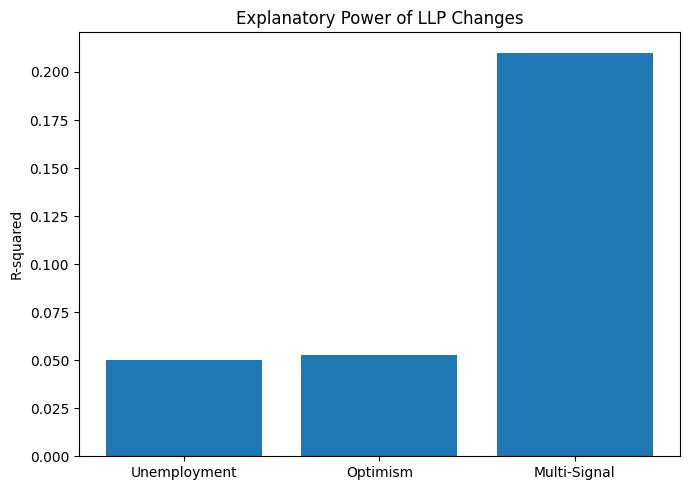

In [8]:
# model comparison

models = ["Unemployment", "Optimism", "Multi-Signal"]
r2_values = [
    model_unemp.rsquared,
    model_opt.rsquared,
    model_multi.rsquared
]

plt.figure(figsize=(7,5))
plt.bar(models, r2_values)

plt.ylabel("R-squared")
plt.title("Explanatory Power of LLP Changes")

plt.tight_layout()
#plt.savefig("../figures/r2_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
#plt.savefig("../figures/r2_comparison.png", dpi=300, bbox_inches='tight')

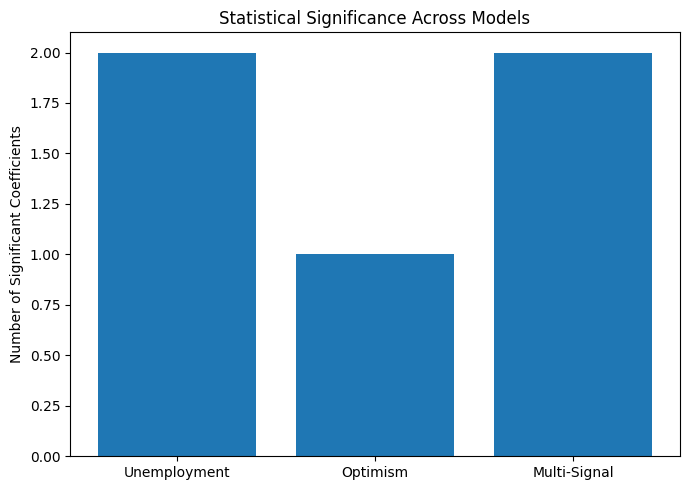

In [9]:
# Count significant coefficients (p < 0.05)

def count_significant(model):
    pvals = model.pvalues.drop("const")
    return (pvals < 0.05).sum()

sig_counts = [
    count_significant(model_unemp),
    count_significant(model_opt),
    count_significant(model_multi)
]

models = ["Unemployment", "Optimism", "Multi-Signal"]

plt.figure(figsize=(7,5))
plt.bar(models, sig_counts)

plt.ylabel("Number of Significant Coefficients")
plt.title("Statistical Significance Across Models")

plt.tight_layout()
plt.show()

In [10]:
# regression summary

from statsmodels.iolib.summary2 import summary_col

results_table = summary_col(
    [model_unemp, model_opt, model_multi],
    stars=True,
    float_format='%0.4f',
    model_names=['Unemployment', 'Optimism', 'Multi-Signal'],
    info_dict={
        'N':lambda x: f"{int(x.nobs)}",
        'R²':lambda x: f"{x.rsquared:.3f}"
    }
)

print(results_table)


               Unemployment  Optimism  Multi-Signal
---------------------------------------------------
const          -0.0000      -0.0000    0.0000      
               (0.0001)     (0.0001)   (0.0001)    
dunemp_lag0    0.0002*                 -0.0002     
               (0.0001)                (0.0002)    
dunemp_lag1    -0.0003**               -0.0002     
               (0.0001)                (0.0002)    
dunemp_lag2    -0.0001                 -0.0003     
               (0.0001)                (0.0002)    
dunemp_lag3    -0.0002***              -0.0006*    
               (0.0001)                (0.0003)    
doptimism_lag0              -0.0002*** -0.0002***  
                            (0.0001)   (0.0001)    
doptimism_lag1              0.0000     0.0001      
                            (0.0001)   (0.0001)    
doptimism_lag2              -0.0001    -0.0001     
                            (0.0000)   (0.0001)    
doptimism_lag3              0.0000     -0.0000     
           

In [11]:
results_table = summary_col(
    [model_unemp, model_opt, model_multi],
    stars=True,
    float_format='%0.4f',
    model_names=['Unemployment', 'Optimism', 'Multi-Signal'],
    regressor_order=[
        'dunemp_lag0','dunemp_lag1','dunemp_lag2','dunemp_lag3',
        'doptimism_lag0','doptimism_lag1','doptimism_lag2','doptimism_lag3'
    ],
    info_dict={
        'N':lambda x: f"{int(x.nobs)}",
        'R²':lambda x: f"{x.rsquared:.3f}"
    }
)

print(results_table)


               Unemployment  Optimism  Multi-Signal
---------------------------------------------------
dunemp_lag0    0.0002*                 -0.0002     
               (0.0001)                (0.0002)    
dunemp_lag1    -0.0003**               -0.0002     
               (0.0001)                (0.0002)    
dunemp_lag2    -0.0001                 -0.0003     
               (0.0001)                (0.0002)    
dunemp_lag3    -0.0002***              -0.0006*    
               (0.0001)                (0.0003)    
doptimism_lag0              -0.0002*** -0.0002***  
                            (0.0001)   (0.0001)    
doptimism_lag1              0.0000     0.0001      
                            (0.0001)   (0.0001)    
doptimism_lag2              -0.0001    -0.0001     
                            (0.0000)   (0.0001)    
doptimism_lag3              0.0000     -0.0000     
                            (0.0001)   (0.0001)    
const          -0.0000      -0.0000    0.0000      
           

In [12]:
with open("../figures/regression_results.txt", "w") as f:
    f.write(results_table.as_text())

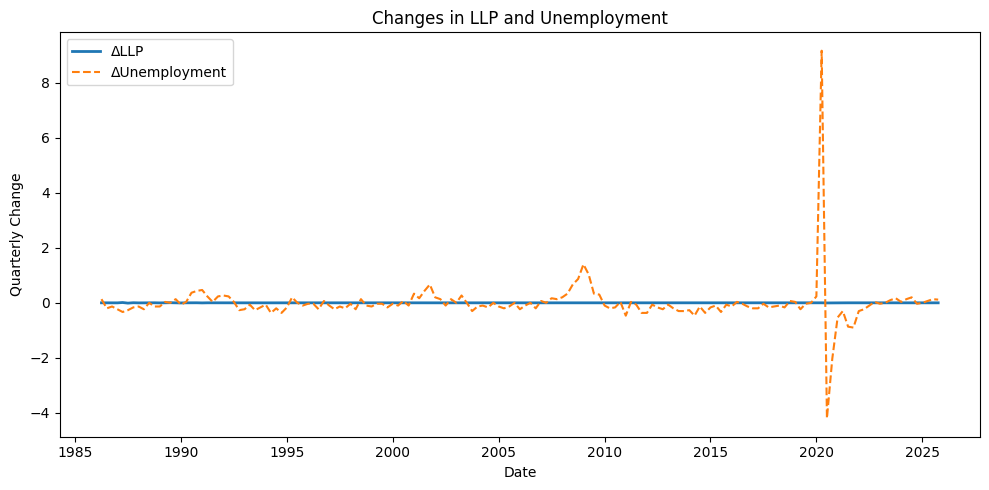

In [13]:
# ================================
# ΔLLP vs ΔUnemployment Plot
# ================================

import matplotlib.pyplot as plt

# Ensure differences exist
df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()

# Drop NA from differencing
df_plot = df[["dllp_ratio", "dunemp"]].dropna()

# Plot
plt.figure(figsize=(10,5))

plt.plot(df_plot.index, df_plot["dllp_ratio"], label="ΔLLP", linewidth=2)
plt.plot(df_plot.index, df_plot["dunemp"], label="ΔUnemployment", linestyle="--")

plt.title("Changes in LLP and Unemployment")
plt.xlabel("Date")
plt.ylabel("Quarterly Change")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/dllp_vs_dunemp.png", dpi=300)
plt.show()

In [14]:
print(df["llp_ratio"].head())
print(df["llp_ratio"].describe())

print(df["dllp_ratio"].describe())

DATE
1986-01-01    0.003291
1986-04-01    0.003788
1986-07-01    0.003519
1986-10-01    0.004691
1987-01-01    0.003487
Name: llp_ratio, dtype: float64
count    160.000000
mean       0.002853
std        0.002340
min       -0.001402
25%        0.001494
50%        0.001932
75%        0.003527
max        0.014789
Name: llp_ratio, dtype: float64
count    159.000000
mean      -0.000011
std        0.001635
min       -0.010939
25%       -0.000250
50%        0.000003
75%        0.000309
max        0.011302
Name: dllp_ratio, dtype: float64


In [16]:
df_plot = df[["dllp_ratio", "dunemp"]].dropna()

df_plot_std = (df_plot - df_plot.mean()) / df_plot.std()

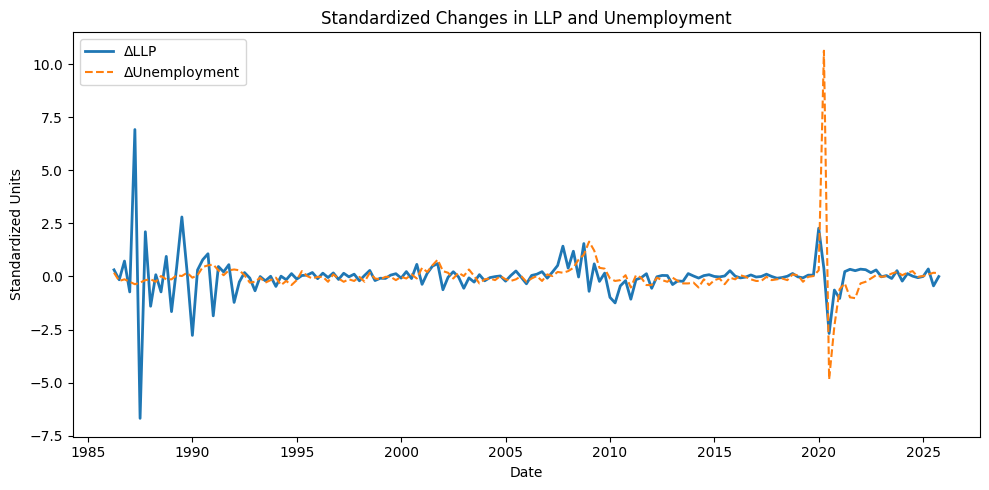

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df_plot_std.index, df_plot_std["dllp_ratio"], label="ΔLLP", linewidth=2)
plt.plot(df_plot_std.index, df_plot_std["dunemp"], label="ΔUnemployment", linestyle="--")

plt.title("Standardized Changes in LLP and Unemployment")
plt.xlabel("Date")
plt.ylabel("Standardized Units")
plt.legend()

plt.tight_layout()
#plt.savefig("../figures/dllp_vs_dunemp_std.png", dpi=300)
plt.show()